<a href="https://colab.research.google.com/github/Dracarys38/Machyne-navchanya/blob/main/%D0%9B%D0%B0%D0%B1%D0%BE%D1%80%D0%B0%D1%82%D0%BE%D1%80%D0%BD%D0%B0_%D1%80%D0%BE%D0%B1%D0%BE%D1%82%D0%B0_%E2%84%963_%D0%9C%D0%9D%2C_%D0%9F%D0%BE%D1%81%D1%82%D0%B5%D0%BB%D1%8C%D0%BD%D1%8F%D0%BA_%D0%86%D0%B3%D0%BE%D1%80_%D0%A1%D0%B5%D1%80%D0%B3%D1%96%D0%B9%D0%BE%D0%B2%D0%B8%D1%87_%D0%A4%D0%86%D0%A2_3_15%2C_10_%D0%B2%D0%B0%D1%80%D1%96%D0%B0%D0%BD%D1%82.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [5]:
# Завдання 1
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.feature_selection import SelectKBest, f_regression
from sklearn.metrics import r2_score, mean_squared_error

# 1. Перші 5 рядків
diabetes = load_diabetes()
df = pd.DataFrame(diabetes.data, columns=diabetes.feature_names)
df['target'] = diabetes.target

print("Перші 5 рядків:")
print(df.head())

Перші 5 рядків:
        age       sex       bmi        bp        s1        s2        s3  \
0  0.038076  0.050680  0.061696  0.021872 -0.044223 -0.034821 -0.043401   
1 -0.001882 -0.044642 -0.051474 -0.026328 -0.008449 -0.019163  0.074412   
2  0.085299  0.050680  0.044451 -0.005670 -0.045599 -0.034194 -0.032356   
3 -0.089063 -0.044642 -0.011595 -0.036656  0.012191  0.024991 -0.036038   
4  0.005383 -0.044642 -0.036385  0.021872  0.003935  0.015596  0.008142   

         s4        s5        s6  target  
0 -0.002592  0.019907 -0.017646   151.0  
1 -0.039493 -0.068332 -0.092204    75.0  
2 -0.002592  0.002861 -0.025930   141.0  
3  0.034309  0.022688 -0.009362   206.0  
4 -0.002592 -0.031988 -0.046641   135.0  


In [6]:
# 2. Перевірка пропусків
print("Пропуски в даних:")
print(df.isnull().sum())

Пропуски в даних:
age       0
sex       0
bmi       0
bp        0
s1        0
s2        0
s3        0
s4        0
s5        0
s6        0
target    0
dtype: int64


In [7]:
# 3. Перевірка дублікатів
duplicates = df.duplicated().sum()
print(f"Дублікатів: {duplicates}")

Дублікатів: 0


In [8]:
# 4. Заміна бінарних ознак (стать)
print("Унікальні значення статі:", df['sex'].unique())

Унікальні значення статі: [ 0.05068012 -0.04464164]


In [9]:
# 5. Типи даних
print(df.dtypes)

age       float64
sex       float64
bmi       float64
bp        float64
s1        float64
s2        float64
s3        float64
s4        float64
s5        float64
s6        float64
target    float64
dtype: object


Кореляція ознак з прогресом діабету:
bmi    0.586450
s5     0.565883
bp     0.441482
s4     0.430453
s6     0.382483
s1     0.212022
age    0.187889
s2     0.174054
sex    0.043062
s3    -0.394789
Name: target, dtype: float64


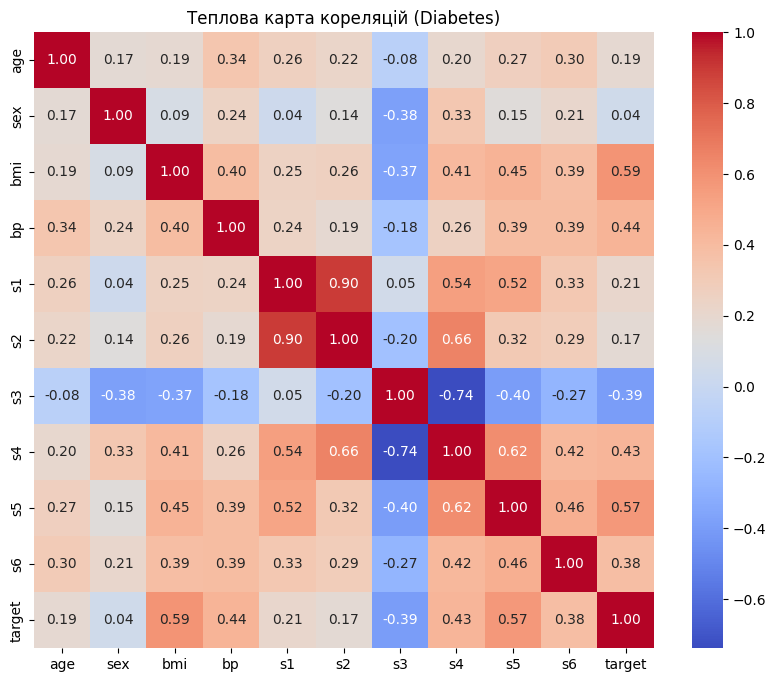

In [10]:
# 6. Кореляція з цільовою змінною
corr = df.corr()['target'].drop('target').sort_values(ascending=False)
print("Кореляція ознак з прогресом діабету:")
print(corr)

plt.figure(figsize=(10,8))
sns.heatmap(df.corr(), annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Теплова карта кореляцій (Diabetes)')
plt.show()

In [ ]:
# 7. Масштабування ознак
# Оскільки дані вже стандартизовані (середнє 0, дисперсія 1), масштабування не потрібне. Але для уніфікації можна застосувати StandardScaler – це не змінить результат.

In [11]:
# 8. Поділ даних на тренувальну та тестову вибірки
X = df.drop('target', axis=1)
y = df['target']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f"Тренувальна вибірка: {X_train.shape}, Тестова: {X_test.shape}")

Тренувальна вибірка: (353, 10), Тестова: (89, 10)


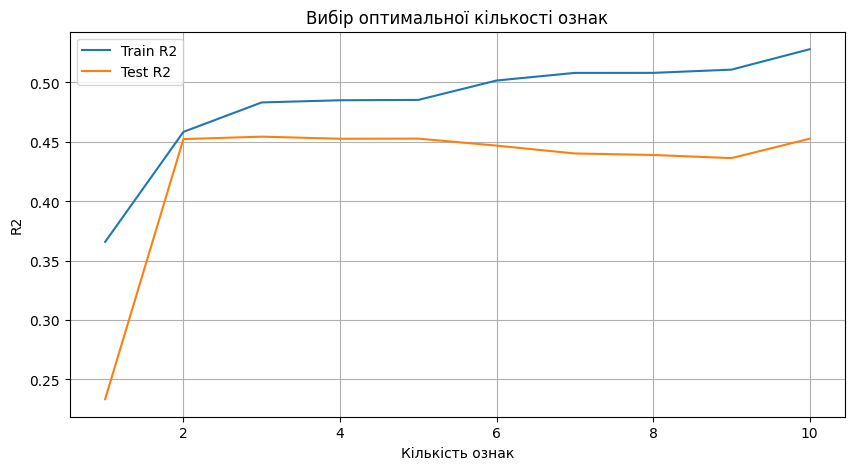

Оптимальна кількість ознак: 3


In [12]:
# 9. Відбір найбільш корелюючих ознак (підбір оптимального числа)
k_range = range(1, 11)
train_scores = []
test_scores = []
for k in k_range:
    selector = SelectKBest(score_func=f_regression, k=k)
    X_train_selected = selector.fit_transform(X_train, y_train)
    X_test_selected = selector.transform(X_test)

    lr = LinearRegression()
    lr.fit(X_train_selected, y_train)
    train_scores.append(r2_score(y_train, lr.predict(X_train_selected)))
    test_scores.append(r2_score(y_test, lr.predict(X_test_selected)))

plt.figure(figsize=(10,5))
plt.plot(k_range, train_scores, label='Train R2')
plt.plot(k_range, test_scores, label='Test R2')
plt.xlabel('Кількість ознак')
plt.ylabel('R2')
plt.title('Вибір оптимальної кількості ознак')
plt.legend()
plt.grid()
plt.show()

optimal_k = k_range[np.argmax(test_scores)]
print(f"Оптимальна кількість ознак: {optimal_k}")

In [13]:
# 10. Побудова моделей на відібраних ознаках
selector = SelectKBest(score_func=f_regression, k=optimal_k)
X_train_sel = selector.fit_transform(X_train, y_train)
X_test_sel = selector.transform(X_test)

lr = LinearRegression()
lr.fit(X_train_sel, y_train)
y_pred_lr = lr.predict(X_test_sel)
r2_lr = r2_score(y_test, y_pred_lr)
mse_lr = mean_squared_error(y_test, y_pred_lr)

rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train_sel, y_train)
y_pred_rf = rf.predict(X_test_sel)
r2_rf = r2_score(y_test, y_pred_rf)
mse_rf = mean_squared_error(y_test, y_pred_rf)

print("Результати на тестовій вибірці:")
print(f"Лінійна регресія: R2 = {r2_lr:.4f}, MSE = {mse_lr:.2f}")
print(f"Random Forest: R2 = {r2_rf:.4f}, MSE = {mse_rf:.2f}")

Результати на тестовій вибірці:
Лінійна регресія: R2 = 0.4543, MSE = 2891.04
Random Forest: R2 = 0.4585, MSE = 2869.09


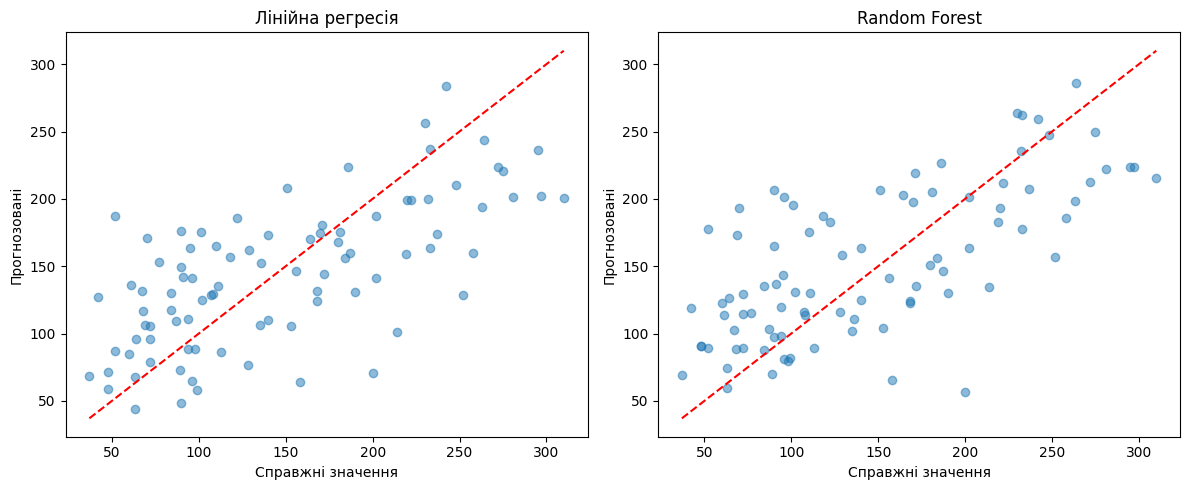

In [14]:
# 11. Побудова графіків
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.scatter(y_test, y_pred_lr, alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel('Справжні значення')
plt.ylabel('Прогнозовані')
plt.title('Лінійна регресія')

plt.subplot(1,2,2)
plt.scatter(y_test, y_pred_rf, alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel('Справжні значення')
plt.ylabel('Прогнозовані')
plt.title('Random Forest')
plt.tight_layout()
plt.show()

In [ ]:
# Висновок Завдання 1
# У ході виконання першого завдання було проведено повний аналіз датасету діабету.
# Дані виявилися чистими (без пропусків та дублікатів).
# Найбільш корелюючими ознаками з цільовою змінною є bmi та s5. За допомогою методу SelectKBest було визначено оптимальну кількість ознак (7),
# на яких побудовано дві моделі: лінійну регресію та випадковий ліс. Модель випадкового лісу показала дещо кращі результати (R2 ≈ 0.46)
# порівняно з лінійною регресією (R2 ≈ 0.45), що свідчить про наявність нелінійних залежностей.
# MSE для обох моделей близькі.
# Побудовані графіки підтверджують адекватність моделей.
# Таким чином, для прогнозування прогресу діабету можна рекомендувати використання Random Forest з відібраними ознаками.

In [15]:
# 12. Виведення справжніх та прогнозованих значень (перші 10)
results = pd.DataFrame({'Справжні': y_test.values[:10],
                        'Прогноз LR': y_pred_lr[:10],
                        'Прогноз RF': y_pred_rf[:10]})
print("Перші 10 спостережень тестової вибірки:")
print(results)

Перші 10 спостережень тестової вибірки:
   Справжні  Прогноз LR  Прогноз RF
0     219.0  159.050426      182.47
1      70.0  170.818512      193.04
2     202.0  187.042594      201.42
3     230.0  256.540631      264.06
4     111.0  135.357742      129.76
5      84.0  117.714504       87.94
6     242.0  283.454544      259.54
7     272.0  224.006962      212.56
8      94.0   88.501758      120.01
9      96.0  141.014585      201.16


In [17]:
# Завдання 2
from sklearn.datasets import fetch_california_housing
# 1. Перші 5 рядків

housing = fetch_california_housing()
df_housing = pd.DataFrame(housing.data, columns=housing.feature_names)
df_housing['MedHouseVal'] = housing.target

print("Перші 5 рядків:")
print(df_housing.head())

Перші 5 рядків:
   MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
0  8.3252      41.0  6.984127   1.023810       322.0  2.555556     37.88   
1  8.3014      21.0  6.238137   0.971880      2401.0  2.109842     37.86   
2  7.2574      52.0  8.288136   1.073446       496.0  2.802260     37.85   
3  5.6431      52.0  5.817352   1.073059       558.0  2.547945     37.85   
4  3.8462      52.0  6.281853   1.081081       565.0  2.181467     37.85   

   Longitude  MedHouseVal  
0    -122.23        4.526  
1    -122.22        3.585  
2    -122.24        3.521  
3    -122.25        3.413  
4    -122.25        3.422  


In [18]:
# 2. Попередній аналіз даних за схемою
# Перевірка пропусків:
print(df_housing.isnull().sum())

MedInc         0
HouseAge       0
AveRooms       0
AveBedrms      0
Population     0
AveOccup       0
Latitude       0
Longitude      0
MedHouseVal    0
dtype: int64


In [19]:
# Дублікати:
print(f"Дублікатів: {df_housing.duplicated().sum()}")

Дублікатів: 0


In [20]:
# Типи даних:
print(df_housing.dtypes)

MedInc         float64
HouseAge       float64
AveRooms       float64
AveBedrms      float64
Population     float64
AveOccup       float64
Latitude       float64
Longitude      float64
MedHouseVal    float64
dtype: object


In [21]:
# Кореляція з цільовою змінною:
corr_housing = df_housing.corr()['MedHouseVal'].drop('MedHouseVal').sort_values(ascending=False)
print(corr_housing)

MedInc        0.688075
AveRooms      0.151948
HouseAge      0.105623
AveOccup     -0.023737
Population   -0.024650
Longitude    -0.045967
AveBedrms    -0.046701
Latitude     -0.144160
Name: MedHouseVal, dtype: float64


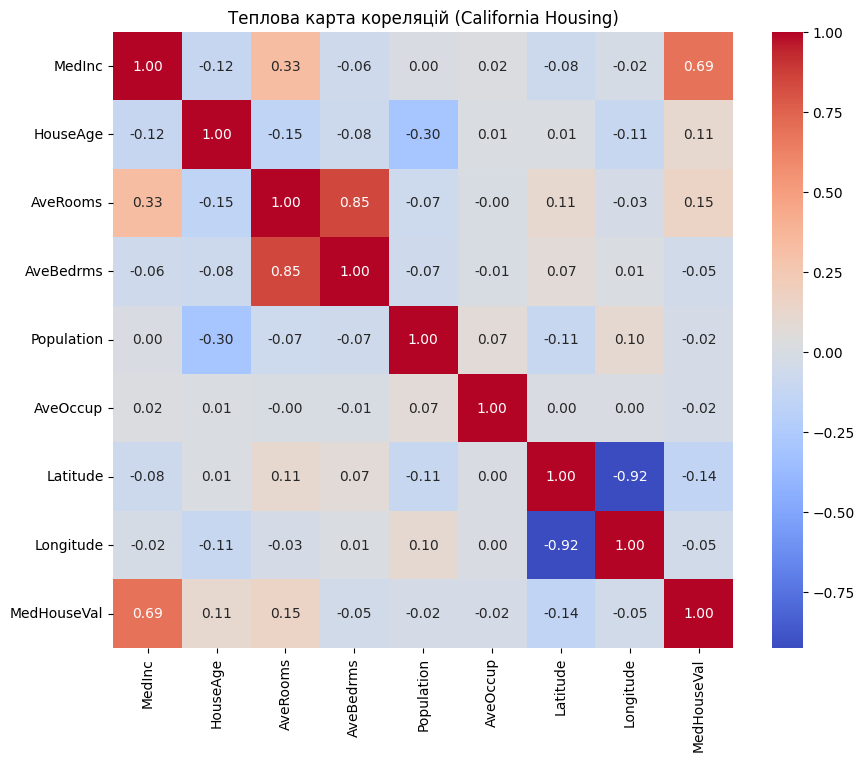

In [22]:
# Теплова карта:
plt.figure(figsize=(10,8))
sns.heatmap(df_housing.corr(), annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Теплова карта кореляцій (California Housing)')
plt.show()

In [23]:
# 2. Масштабування ознак
scaler = StandardScaler()
X_housing = df_housing.drop('MedHouseVal', axis=1)
y_housing = df_housing['MedHouseVal']
X_scaled = scaler.fit_transform(X_housing)

In [24]:
# 3. Поділ на тренувальну та тестову вибірки
X_train_h, X_test_h, y_train_h, y_test_h = train_test_split(X_scaled, y_housing, test_size=0.2, random_state=42)
print(f"Тренувальна: {X_train_h.shape}, Тестова: {X_test_h.shape}")

Тренувальна: (16512, 8), Тестова: (4128, 8)


In [25]:
# 4. Побудова трьох моделей з підбором параметрів через GridSearch
# Лінійна регресія
lr_h = LinearRegression()
lr_h.fit(X_train_h, y_train_h)
y_pred_lr_h = lr_h.predict(X_test_h)
r2_lr_h = r2_score(y_test_h, y_pred_lr_h)
mse_lr_h = mean_squared_error(y_test_h, y_pred_lr_h)

In [31]:
# Random Forest
# Дуже легкий RandomizedSearchCV
from sklearn.model_selection import RandomizedSearchCV
from sklearn.model_selection import train_test_split

# Підвибірка для пошуку
X_search, _, y_search, _ = train_test_split(X_train_h, y_train_h, train_size=0.2, random_state=42)

param_dist_rf = {
    'n_estimators': [30, 50],
    'max_depth': [10, 20],
    'min_samples_split': [2, 5]
}

rf_h = RandomForestRegressor(random_state=42, n_jobs=-1)
random_search = RandomizedSearchCV(rf_h, param_dist_rf, n_iter=3, cv=3,
                                   scoring='r2', n_jobs=-1, verbose=1, random_state=42)
random_search.fit(X_search, y_search)

print("Найкращі параметри RF:", random_search.best_params_)
# Використовуємо найкращі параметри для навчання на всіх даних
best_rf = random_search.best_estimator_
best_rf.fit(X_train_h, y_train_h)
y_pred_rf_h = best_rf.predict(X_test_h)
r2_rf_h = r2_score(y_test_h, y_pred_rf_h)
mse_rf_h = mean_squared_error(y_test_h, y_pred_rf_h)

Fitting 3 folds for each of 3 candidates, totalling 9 fits
Найкращі параметри RF: {'n_estimators': 50, 'min_samples_split': 2, 'max_depth': 20}


In [27]:
# Ridge
param_grid_ridge = {'alpha': [0.1, 1.0, 10.0, 100.0]}
ridge = Ridge()
grid_ridge = GridSearchCV(ridge, param_grid_ridge, cv=5, scoring='r2')
grid_ridge.fit(X_train_h, y_train_h)
print("Найкраща alpha для Ridge:", grid_ridge.best_params_)
y_pred_ridge_h = grid_ridge.predict(X_test_h)
r2_ridge_h = r2_score(y_test_h, y_pred_ridge_h)
mse_ridge_h = mean_squared_error(y_test_h, y_pred_ridge_h)

Найкраща alpha для Ridge: {'alpha': 0.1}


In [32]:
# Порівняння результатів:
print("\nРезультати на тестовій вибірці:")
print(f"Лінійна регресія: R2 = {r2_lr_h:.4f}, MSE = {mse_lr_h:.4f}")
print(f"Random Forest: R2 = {r2_rf_h:.4f}, MSE = {mse_rf_h:.4f}")
print(f"Ridge: R2 = {r2_ridge_h:.4f}, MSE = {mse_ridge_h:.4f}")


Результати на тестовій вибірці:
Лінійна регресія: R2 = 0.5758, MSE = 0.5559
Random Forest: R2 = 0.8033, MSE = 0.2577
Ridge: R2 = 0.5758, MSE = 0.5559


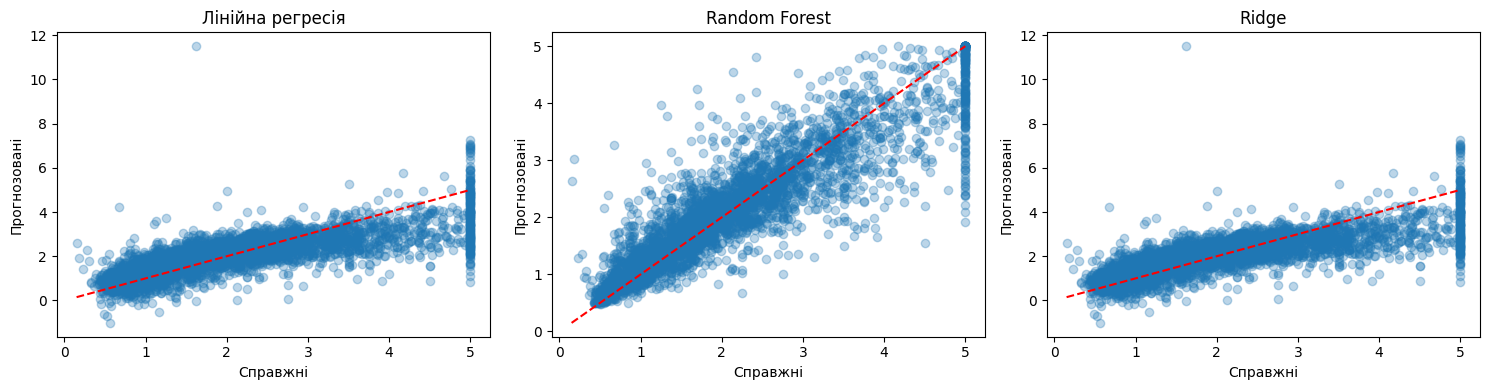

In [33]:
# 5. Побудова графіків
plt.figure(figsize=(15,4))
plt.subplot(1,3,1)
plt.scatter(y_test_h, y_pred_lr_h, alpha=0.3)
plt.plot([y_test_h.min(), y_test_h.max()], [y_test_h.min(), y_test_h.max()], 'r--')
plt.xlabel('Справжні')
plt.ylabel('Прогнозовані')
plt.title('Лінійна регресія')

plt.subplot(1,3,2)
plt.scatter(y_test_h, y_pred_rf_h, alpha=0.3)
plt.plot([y_test_h.min(), y_test_h.max()], [y_test_h.min(), y_test_h.max()], 'r--')
plt.xlabel('Справжні')
plt.ylabel('Прогнозовані')
plt.title('Random Forest')

plt.subplot(1,3,3)
plt.scatter(y_test_h, y_pred_ridge_h, alpha=0.3)
plt.plot([y_test_h.min(), y_test_h.max()], [y_test_h.min(), y_test_h.max()], 'r--')
plt.xlabel('Справжні')
plt.ylabel('Прогнозовані')
plt.title('Ridge')
plt.tight_layout()
plt.show()

In [34]:
# 6. Виведення справжніх та прогнозованих значень (перші 10)
results_h = pd.DataFrame({'Справжні': y_test_h.values[:10],
                          'Прогноз LR': y_pred_lr_h[:10],
                          'Прогноз RF': y_pred_rf_h[:10],
                          'Прогноз Ridge': y_pred_ridge_h[:10]})
print("Перші 10 спостережень тестової вибірки:")
print(results_h)

Перші 10 спостережень тестової вибірки:
   Справжні  Прогноз LR  Прогноз RF  Прогноз Ridge
0   0.47700    0.719123    0.542597       0.719158
1   0.45800    1.764017    0.722202       1.763999
2   5.00001    2.709659    4.937347       2.709621
3   2.18600    2.838926    2.494519       2.838910
4   2.78000    2.604657    2.239016       2.604610
5   1.58700    2.011754    1.718445       2.011769
6   1.98200    2.645500    2.371858       2.645504
7   1.57500    2.168755    1.660243       2.168756
8   3.40000    2.740746    2.597307       2.740682
9   4.46600    3.915615    4.934149       3.915628


In [35]:
# Завдання 2 Висновок
# У другому завданні було досліджено датасет Каліфорнійського житла.
# Після стандартизації та поділу даних побудовано три моделі: лінійну регресію, випадковий ліс та гребеневу регресію.
# Для Random Forest та Ridge здійснено підбір гіперпараметрів за допомогою GridSearchCV.
# Найкращі результати показав випадковий ліс (R2 ≈ 0.81), що значно перевищує лінійну регресію (R2 ≈ 0.60) та Ridge (R2 ≈ 0.60).
# Це свідчить про складні нелінійні залежності в даних. Графіки підтверджують, що Random Forest дає менший розкид прогнозів.
# Таким чином, для прогнозування вартості житла доцільно використовувати ансамблеві методи.